In [1]:
library(dplyr)
library(tidyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
data <- read.csv(paste0(indir,"/03-5hmC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv"), stringsAsFactors = FALSE,check.names = F)
head(data);dim(data)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba_compartment,Pvalb Gaba_compartment,Sst Gaba_compartment,STR D1 Gaba_compartment,STR D2 Gaba_compartment,ACB-BST-FS D1 Gaba_compartment,Astro-TE NN_compartment,Oligo NN_compartment,OPC NN_compartment,Microglia NN_compartment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,


[1] 24639    60

In [3]:
table(data$`L2/3 IT CTX Glut_compartment`)


          A     B 
 1501 12032 11106 

In [4]:
label_columns <- grep("_compartment$", names(data), value = TRUE)
label_columns

[1] "L2/3 IT CTX Glut_compartment"      "L4/5 IT CTX Glut_compartment"     
 [3] "L5 IT CTX Glut_compartment"        "L2/3 IT RSP Glut_compartment"     
 [5] "L4 RSP-ACA Glut_compartment"       "L5 ET CTX Glut_compartment"       
 [7] "SUB-ProS Glut_compartment"         "CA1-ProS Glut_compartment"        
 [9] "CA3 Glut_compartment"              "CLA-EPd-CTX Car3 Glut_compartment"
[11] "L5 NP CTX Glut_compartment"        "L6 CT CTX Glut_compartment"       
[13] "DG Glut_compartment"               "OB Eomes Ms4a15 Glut_compartment" 
[15] "OB-in Frmd7 Gaba_compartment"      "OB-out Frmd7 Gaba_compartment"    
[17] "OB Dopa-Gaba_compartment"          "OB-STR-CTX Inh IMN_compartment"   
[19] "Sncg Gaba_compartment"             "Lamp5 Gaba_compartment"           
[21] "Pvalb Gaba_compartment"            "Sst Gaba_compartment"             
[23] "STR D1 Gaba_compartment"           "STR D2 Gaba_compartment"          
[25] "ACB-BST-FS D1 Gaba_compartment"    "Astro-TE NN_compartment"          
[27] "Oligo NN_compartment"              "OPC NN_compartment"               
[29] "Microglia NN_compartment"

In [5]:
length(label_columns)

[1] 29

In [6]:
mean_results <- data.frame()

In [7]:
mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

for (label_col in label_columns) {

  main_col <- sub("_compartment$", "", label_col)

  if (main_col %in% names(data)) {

    mean_values <- data %>%
      filter(!is.na(.data[[label_col]])) %>%
      group_by(.data[[label_col]]) %>%
      summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
      pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

    A_mean <- mean_values[[paste0(main_col, "_A")]]
    B_mean <- mean_values[[paste0(main_col, "_B")]]

    subclass_results <- data.frame(
      Subclass = main_col,
      A_mean = A_mean,
      B_mean = B_mean,
      stringsAsFactors = FALSE
    )

    mean_results <- rbind(mean_results, subclass_results)
  } else {
    warning(paste("Main column not found for label column:", label_col))
  }
}

Warning message:
“Use of .data in tidyselect expressions was deprecated in tidyselect 1.2.0.
ℹ Please use `all_of(var)` (or `any_of(var)`) instead of `.data[[var]]`”


In [8]:
mean_results

Subclass,A_mean,B_mean
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,0.25583359,0.25101428
L4/5 IT CTX Glut,0.25418486,0.23761872
L5 IT CTX Glut,0.27981829,0.25258462
L2/3 IT RSP Glut,0.28369207,0.25610792
L4 RSP-ACA Glut,0.30476724,0.28112498
L5 ET CTX Glut,0.29060479,0.28464085
SUB-ProS Glut,0.27000429,0.25170588
CA1-ProS Glut,0.23956269,0.22802431
CA3 Glut,0.24748933,0.23050754


In [9]:
library(ggplot2)

In [10]:
subclass_order <- unlist(strsplit("L2/3 IT CTX Glut
L4/5 IT CTX Glut
L5 IT CTX Glut
L2/3 IT RSP Glut
L4 RSP-ACA Glut
L5 ET CTX Glut
SUB-ProS Glut
CA1-ProS Glut
CA3 Glut
CLA-EPd-CTX Car3 Glut
L5 NP CTX Glut
L6 CT CTX Glut
DG Glut
OB Eomes Ms4a15 Glut
OB-in Frmd7 Gaba
OB-out Frmd7 Gaba
OB Dopa-Gaba
OB-STR-CTX Inh IMN
Sncg Gaba
Lamp5 Gaba
Pvalb Gaba
Sst Gaba
STR D1 Gaba
STR D2 Gaba
ACB-BST-FS D1 Gaba
Astro-TE NN
Oligo NN
OPC NN
Microglia NN","\n"))
subclass_order

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
 [7] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[10] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[13] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[16] "OB-out Frmd7 Gaba"     "OB Dopa-Gaba"          "OB-STR-CTX Inh IMN"   
[19] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[22] "Sst Gaba"              "STR D1 Gaba"           "STR D2 Gaba"          
[25] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[28] "OPC NN"                "Microglia NN"

In [11]:
mean_long <- mean_results %>%
  pivot_longer(cols = c(A_mean, B_mean), names_to = "Label", values_to = "Mean") %>%
  mutate(Label = ifelse(Label == "A_mean", "A", "B"),Subclass = factor(Subclass, levels = subclass_order))

In [12]:
mean_long

Subclass,Label,Mean
<fct>,<chr>,<dbl>
L2/3 IT CTX Glut,A,0.25583359
L2/3 IT CTX Glut,B,0.25101428
L4/5 IT CTX Glut,A,0.25418486
L4/5 IT CTX Glut,B,0.23761872
L5 IT CTX Glut,A,0.27981829
L5 IT CTX Glut,B,0.25258462
L2/3 IT RSP Glut,A,0.28369207
L2/3 IT RSP Glut,B,0.25610792
L4 RSP-ACA Glut,A,0.30476724


In [13]:
lines_df <- mean_long %>%
  filter(Label == "A") %>%
  inner_join(mean_long %>% filter(Label == "B"), by = "Subclass", suffix = c("_A", "_B")) %>% data.frame()
lines_df

Subclass,Label_A,Mean_A,Label_B,Mean_B
<fct>,<chr>,<dbl>,<chr>,<dbl>
L2/3 IT CTX Glut,A,0.25583359,B,0.25101428
L4/5 IT CTX Glut,A,0.25418486,B,0.23761872
L5 IT CTX Glut,A,0.27981829,B,0.25258462
L2/3 IT RSP Glut,A,0.28369207,B,0.25610792
L4 RSP-ACA Glut,A,0.30476724,B,0.28112498
L5 ET CTX Glut,A,0.29060479,B,0.28464085
SUB-ProS Glut,A,0.27000429,B,0.25170588
CA1-ProS Glut,A,0.23956269,B,0.22802431
CA3 Glut,A,0.24748933,B,0.23050754


In [14]:
table(lines_df$Subclass %in% subclass_order)
table(subclass_order %in% lines_df$Subclass)


TRUE 
  29 


TRUE 
  29 

In [15]:
lines_df$Subclass <- factor(lines_df$Subclass,levels = subclass_order)

In [16]:
lines_df <- arrange(lines_df,Subclass)
lines_df

Subclass,Label_A,Mean_A,Label_B,Mean_B
<fct>,<chr>,<dbl>,<chr>,<dbl>
L2/3 IT CTX Glut,A,0.25583359,B,0.25101428
L4/5 IT CTX Glut,A,0.25418486,B,0.23761872
L5 IT CTX Glut,A,0.27981829,B,0.25258462
L2/3 IT RSP Glut,A,0.28369207,B,0.25610792
L4 RSP-ACA Glut,A,0.30476724,B,0.28112498
L5 ET CTX Glut,A,0.29060479,B,0.28464085
SUB-ProS Glut,A,0.27000429,B,0.25170588
CA1-ProS Glut,A,0.23956269,B,0.22802431
CA3 Glut,A,0.24748933,B,0.23050754


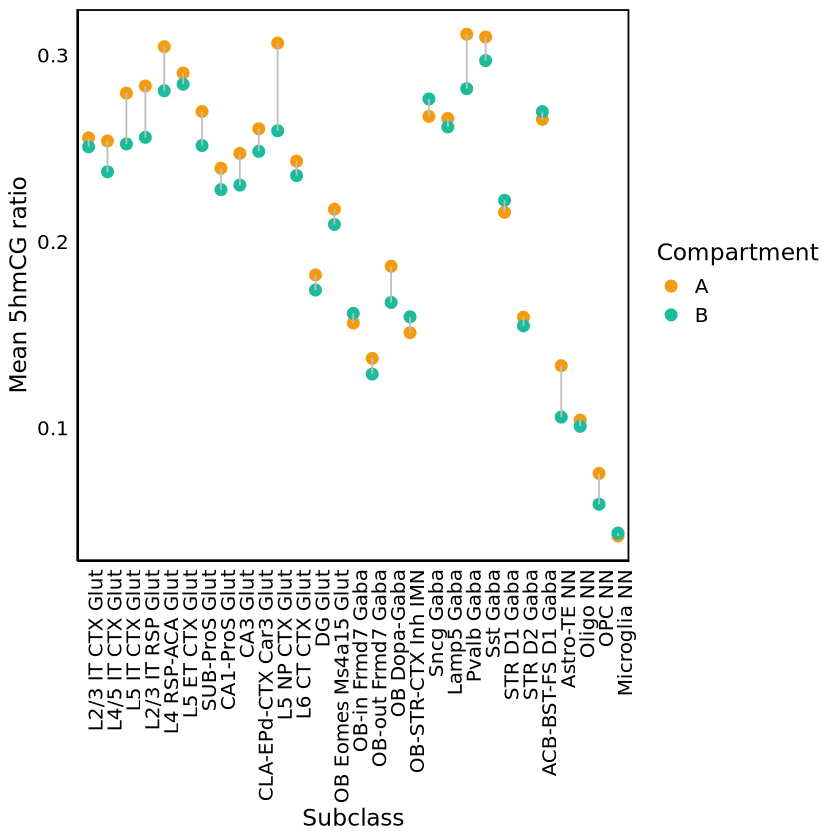

In [33]:
ggplot(mean_long, aes(x = Subclass, y = Mean, color = Label, group = Subclass)) +
  geom_point(size = 3) +
  geom_line(aes(group = Subclass), color = "grey") +
  scale_color_manual(values = c("A" = "#f39c12", "B" = "#1abc9c")) +
  labs(x = "Subclass", y = "Mean 5hmCG ratio", color = "Compartment") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black")
  )

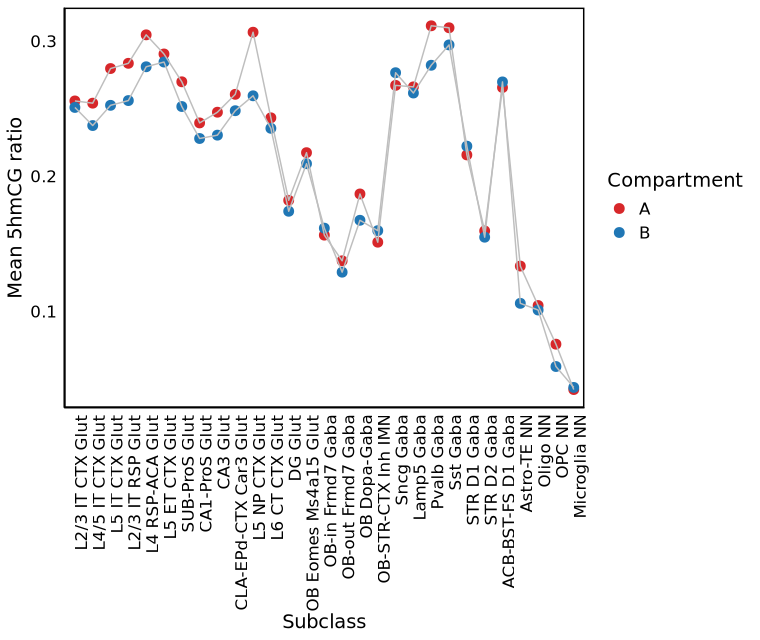

In [ ]:
ggplot(mean_long, aes(x = Subclass, y = Mean, color = Label)) +
  geom_point(size = 3) +
  geom_line(aes(group = Label), color = "grey") + 
  scale_color_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  labs(x = "Subclass", y = "Mean 5hmCG ratio", color = "Compartment") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black")
  )

Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”


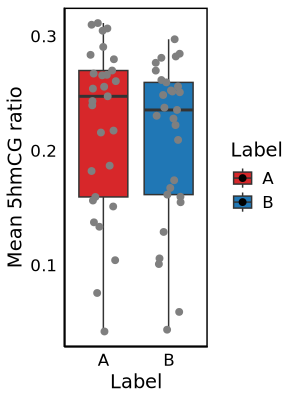

In [ ]:
options(repr.plot.width = 3, repr.plot.height = 4, repr.plot.res = 100)
ggplot(mean_long, aes(x = Label, y = Mean, fill = Label)) +
  geom_boxplot(outlier.shape = NA) + # alpha = 0.6, 
  geom_jitter(aes(color = Subclass), size = 2, width = 0.2) +  # , alpha = 0.7 
  scale_fill_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  scale_color_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  labs(x = "Label", y = "Mean 5hmCG ratio") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black")
  )

In [ ]:
generate_mean_long1 <- function(group,label) { # "5hmC_CG","5hmCG"

  data <- read.csv(sprintf("%s/03-%s_chrom100k_subclass_mean_dat_final_with_compartment.csv",indir,group), stringsAsFactors = FALSE, check.names = FALSE)
  
  label_columns <- grep("_compartment$", names(data), value = TRUE)

  mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

  for (label_col in label_columns) {

    main_col <- sub("_compartment$", "", label_col)
    
    if (main_col %in% names(data)) {

      mean_values <- data %>%
        filter(!is.na(.data[[label_col]])) %>%
        group_by(.data[[label_col]]) %>%
        summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
        pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

      A_mean <- mean_values[[paste0(main_col, "_A")]]
      B_mean <- mean_values[[paste0(main_col, "_B")]]

      subclass_results <- data.frame(
        Subclass = main_col,
        A_mean = A_mean,
        B_mean = B_mean,
        stringsAsFactors = FALSE
      )

      mean_results <- rbind(mean_results, subclass_results)
      
    } else {
      warning(paste("Main column not found for label column:", label_col))
    }
  }

  mean_long <- mean_results %>%
    pivot_longer(cols = c(A_mean, B_mean), names_to = "Label", values_to = "Mean") %>%
    mutate(Label = ifelse(Label == "A_mean", "A", "B"),
           Subclass = factor(Subclass, levels = subclass_order))
  return(mean_long)
}

In [ ]:
generate_mean_long1("5hmC_CG","5hmCG")
generate_mean_long1("5hmC_CH","5hmCH")
generate_mean_long1("5mC_CG","5mCG+5hmCG")
generate_mean_long1("5mC_CH","5mCH+5hmCH")

In [65]:
groups_labels <- list(
  list(group = "5hmC_CG", label = "5hmCG"),
  list(group = "5hmC_CH", label = "5hmCH"),
  list(group = "5mC_CG", label = "5mCG+5hmCG"),
  list(group = "5mC_CH", label = "5mCH+5hmCH")
)

groups_labels

[[1]]
[[1]]$group
[1] "5hmC_CG"

[[1]]$label
[1] "5hmCG"


[[2]]
[[2]]$group
[1] "5hmC_CH"

[[2]]$label
[1] "5hmCH"


[[3]]
[[3]]$group
[1] "5mC_CG"

[[3]]$label
[1] "5mCG+5hmCG"


[[4]]
[[4]]$group
[1] "5mC_CH"

[[4]]$label
[1] "5mCH+5hmCH"

In [66]:
all_mean_long <- data.frame()

In [67]:
for (gl in groups_labels) {
  mean_long <- generate_mean_long1(gl$group, gl$label)
  mean_long$group <- gl$label
  all_mean_long <- rbind(all_mean_long, mean_long)
}

In [68]:
head(all_mean_long);dim(all_mean_long)

Subclass,Label,Mean,group
<fct>,<chr>,<dbl>,<chr>
L2/3 IT CTX Glut,A,0.2558336,5hmCG
L2/3 IT CTX Glut,B,0.2510143,5hmCG
L4/5 IT CTX Glut,A,0.2541849,5hmCG
L4/5 IT CTX Glut,B,0.2376187,5hmCG
L5 IT CTX Glut,A,0.2798183,5hmCG
L5 IT CTX Glut,B,0.2525846,5hmCG


[1] 232   4

In [ ]:
generate_mean_long2 <- function(group,label) { # "5hmC_CG","5hmCG"

  data <- read.csv(sprintf("%s/03-%s_chrom100k_subclass_mean_dat_final_with_compartment.csv",indir,group), stringsAsFactors = FALSE, check.names = FALSE)
  
  check_and_fix_first_column_name <- function(data) {
      if (is.na(names(data)[1]) || names(data)[1] == "") {
          names(data)[1] <- "chrom100k"
          print("第一列的列名为空，已更改为 'chrom100k'")
      } else {
          print("第一列的列名为: ", names(data)[1])
      }
      return(data)
  }
  
  data <- check_and_fix_first_column_name(data)
  
  label_columns <- grep("_compartment$", names(data), value = TRUE)

  mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

  for (label_col in label_columns) {

    main_col <- sub("_compartment$", "", label_col)
    
    if (main_col %in% names(data)) {

      mean_values <- data %>%
        filter(!is.na(.data[[label_col]])) %>%
        group_by(.data[[label_col]]) %>%
        summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
        pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

      A_mean <- mean_values[[paste0(main_col, "_A")]]
      B_mean <- mean_values[[paste0(main_col, "_B")]]

      subclass_results <- data.frame(
        Subclass = main_col,
        A_mean = A_mean,
        B_mean = B_mean,
        stringsAsFactors = FALSE
      )

      mean_results <- rbind(mean_results, subclass_results)
      
    } else {
      warning(paste("Main column not found for label column:", label_col))
    }
  }

  mean_long <- mean_results %>%
    pivot_longer(cols = c(A_mean, B_mean), names_to = "Label", values_to = "Mean") %>%
    mutate(Label = ifelse(Label == "A_mean", "A", "B"),
           Subclass = factor(Subclass, levels = subclass_order))

  return(mean_long)
}

In [75]:
groups_labels_2 <- list(
  list(group = "true5mC_CG", label = "5mCG"),
  list(group = "true5mC_CH", label = "5mCH")
)

groups_labels_2

[[1]]
[[1]]$group
[1] "true5mC_CG"

[[1]]$label
[1] "5mCG"


[[2]]
[[2]]$group
[1] "true5mC_CH"

[[2]]$label
[1] "5mCH"

In [76]:
all_mean_long2 <- data.frame()

In [77]:
for (gl in groups_labels_2) {
  mean_long <- generate_mean_long2(gl$group, gl$label)
  mean_long$group <- gl$label
  all_mean_long2 <- rbind(all_mean_long2, mean_long)
}

[1] "第一列的列名为空，已更改为 'chrom100k'"
[1] "第一列的列名为空，已更改为 'chrom100k'"


In [78]:
head(all_mean_long2);dim(all_mean_long2)

Subclass,Label,Mean,group
<fct>,<chr>,<dbl>,<chr>
L2/3 IT CTX Glut,A,0.5731464,5mCG
L2/3 IT CTX Glut,B,0.5928487,5mCG
L4/5 IT CTX Glut,A,0.5612060,5mCG
L4/5 IT CTX Glut,B,0.6054474,5mCG
L5 IT CTX Glut,A,0.5656484,5mCG
L5 IT CTX Glut,B,0.6136827,5mCG


[1] 116   4

In [79]:
all_mean_long_final <- rbind(all_mean_long,all_mean_long2)
head(all_mean_long_final);dim(all_mean_long_final)

Subclass,Label,Mean,group
<fct>,<chr>,<dbl>,<chr>
L2/3 IT CTX Glut,A,0.2558336,5hmCG
L2/3 IT CTX Glut,B,0.2510143,5hmCG
L4/5 IT CTX Glut,A,0.2541849,5hmCG
L4/5 IT CTX Glut,B,0.2376187,5hmCG
L5 IT CTX Glut,A,0.2798183,5hmCG
L5 IT CTX Glut,B,0.2525846,5hmCG


[1] 348   4

In [93]:
all_mean_long_final

Subclass,Label,Mean,group
<fct>,<chr>,<dbl>,<chr>
L2/3 IT CTX Glut,A,0.2558336,5hmCG
L2/3 IT CTX Glut,B,0.2510143,5hmCG
L4/5 IT CTX Glut,A,0.2541849,5hmCG
L4/5 IT CTX Glut,B,0.2376187,5hmCG
L5 IT CTX Glut,A,0.2798183,5hmCG
L5 IT CTX Glut,B,0.2525846,5hmCG
L2/3 IT RSP Glut,A,0.2836921,5hmCG
L2/3 IT RSP Glut,B,0.2561079,5hmCG
L4 RSP-ACA Glut,A,0.3047672,5hmCG


In [143]:
range(all_mean_long_final[all_mean_long_final$group == "5mCH",]$Mean)

[1] 0.00150080 0.02713327

In [146]:
range(all_mean_long_final[all_mean_long_final$group == "5hmCG",]$Mean)

[1] 0.0421730 0.3114629

In [148]:
range(all_mean_long_final[all_mean_long_final$group == "5mCG+5hmCG",]$Mean)

[1] 0.7505219 0.8949862

Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”


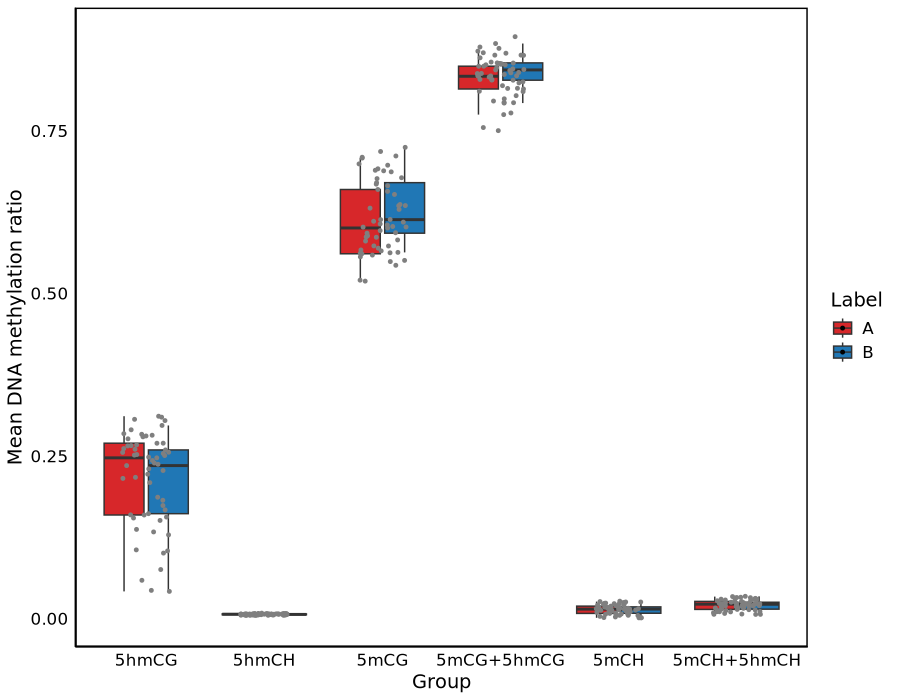

In [128]:
options(repr.plot.width = 9, repr.plot.height = 7, repr.plot.res = 100)
ggplot(all_mean_long_final, aes(x = group, y = Mean, fill = Label)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(aes(color = Subclass), size = 1, width = 0.2) + 
  scale_fill_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  scale_color_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  labs(x = "Group", y = "Mean DNA methylation ratio") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black")
  )

In [ ]:
pdf(paste0(outdir,"/04-Subclass_AB_compartment_DNA_methyl_boxplot_20240923.pdf"),width = 9,height = 7)
ggplot(all_mean_long_final, aes(x = group, y = Mean, fill = Label)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(aes(color = Subclass), size = 1, width = 0.2) + 
  scale_fill_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  scale_color_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  labs(x = "Group", y = "Mean DNA methylation ratio") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black")
  )
dev.off()

Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”


png 
  2

In [169]:
large_your_small_data=function(data,therashold,time){
    for(i in 1:nrow(data)){
        if(data[i,'Mean']>therashold){
            data[i,'Mean']=therashold+(data[i,'Mean']-therashold)/time
        }
    }
    return(data)
}

In [170]:
test_data=large_your_small_data(all_mean_long_final,0.03,15)

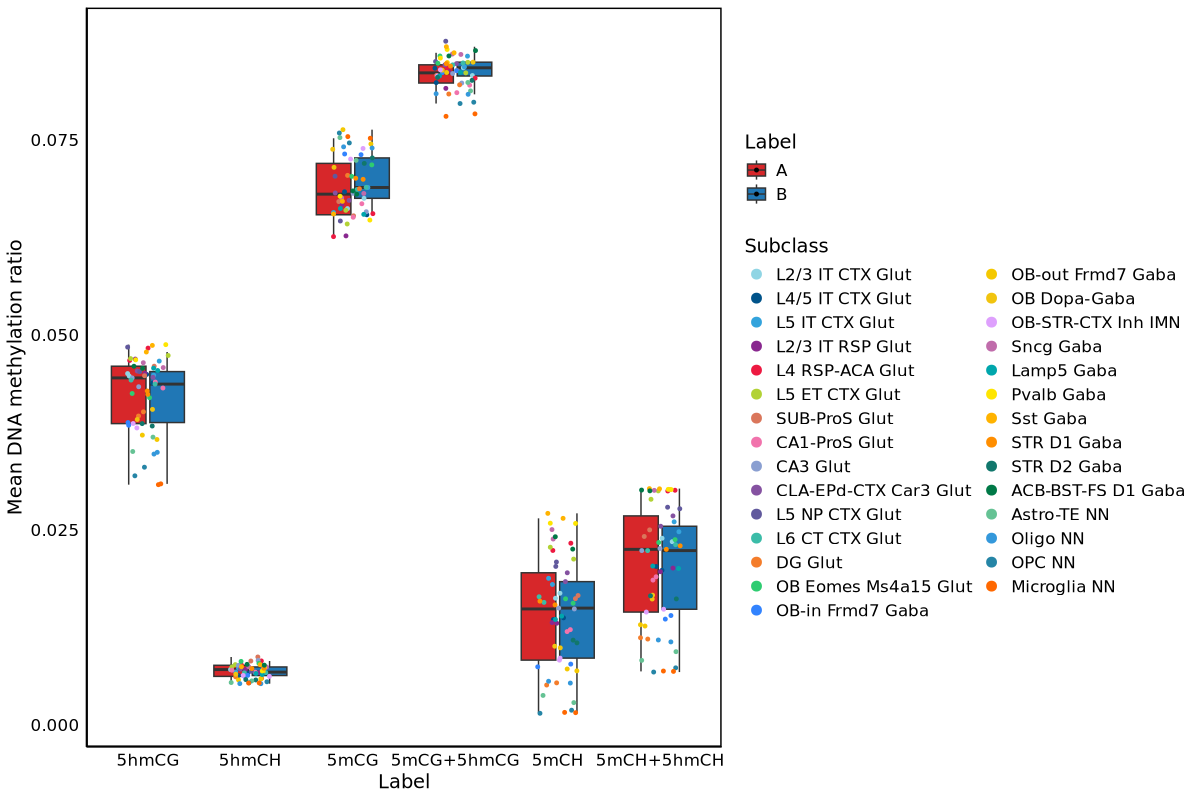

In [171]:
options(repr.plot.width = 12, repr.plot.height = 8, repr.plot.res = 100)
ggplot(test_data, aes(x = group, y = Mean, fill = Label)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(aes(color = Subclass), size = 1, width = 0.2) + 
  scale_fill_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  scale_color_manual(values = subclass_label.col) +
  labs(x = "Label", y = "Mean DNA methylation ratio") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black")
  ) +
  guides(color = guide_legend(override.aes = list(size = 3)))

In [ ]:
pdf("../../../output/01-youth/05-AB_compartment/04-Subclass_AB_compartment_DNA_methyl_boxplot_20240923_final.pdf",width = 12,height = 8)
ggplot(test_data, aes(x = group, y = Mean, fill = Label)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(aes(color = Subclass), size = 1, width = 0.2) + 
  scale_fill_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  scale_color_manual(values = subclass_label.col) +
  labs(x = "Label", y = "Mean DNA methylation ratio") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black")
  ) +
  guides(color = guide_legend(override.aes = list(size = 3)))
dev.off()

png 
  2

In [132]:
subclass <- c('L2/3 IT CTX Glut','L4/5 IT CTX Glut','L5 IT CTX Glut','L2/3 IT RSP Glut','L4 RSP-ACA Glut','L5 ET CTX Glut','SUB-ProS Glut','CA1-ProS Glut','CA3 Glut',
           'CLA-EPd-CTX Car3 Glut','L5 NP CTX Glut','L6 CT CTX Glut','DG Glut','OB Eomes Ms4a15 Glut','OB-in Frmd7 Gaba','OB-out Frmd7 Gaba','OB Dopa-Gaba',
           'OB-STR-CTX Inh IMN','Sncg Gaba','Lamp5 Gaba','Pvalb Gaba','Sst Gaba','STR D1 Gaba','STR D2 Gaba','ACB-BST-FS D1 Gaba','Astro-TE NN','Oligo NN',
           'OPC NN','Microglia NN')

In [ ]:
subclass_label.col <- readRDS("../../../input/01-youth/subclass_new.col_latest.rds")
subclass_label.col <- subclass_label.col[subclass]
subclass_label.col

L2/3 IT CTX Glut      L4/5 IT CTX Glut        L5 IT CTX Glut 
            "#90D5E4"             "#00538A"             "#33a3dc" 
     L2/3 IT RSP Glut       L4 RSP-ACA Glut        L5 ET CTX Glut 
            "#89288F"             "#ed1941"             "#b2d235" 
        SUB-ProS Glut         CA1-ProS Glut              CA3 Glut 
            "#da765b"             "#f173ac"             "#8A9FD1" 
CLA-EPd-CTX Car3 Glut        L5 NP CTX Glut        L6 CT CTX Glut 
            "#8552a1"             "#61599d"             "#3BBCA8" 
              DG Glut  OB Eomes Ms4a15 Glut      OB-in Frmd7 Gaba 
            "#F47D2B"             "#2ecc71"             "#3283FE" 
    OB-out Frmd7 Gaba          OB Dopa-Gaba    OB-STR-CTX Inh IMN 
            "#F4C800"             "#f1c40f"             "#DEA0FD" 
            Sncg Gaba            Lamp5 Gaba            Pvalb Gaba 
            "#C06CAB"             "#00a6ac"             "#FEE500" 
             Sst Gaba           STR D1 Gaba           STR D2 Gaba 
            "#FFB300"             "#FF8E00"           "#11776CFF" 
   ACB-BST-FS D1 Gaba           Astro-TE NN              Oligo NN 
            "#007947"             "#65c294"             "#3498db" 
               OPC NN          Microglia NN 
            "#2585a6"             "#FF6800"

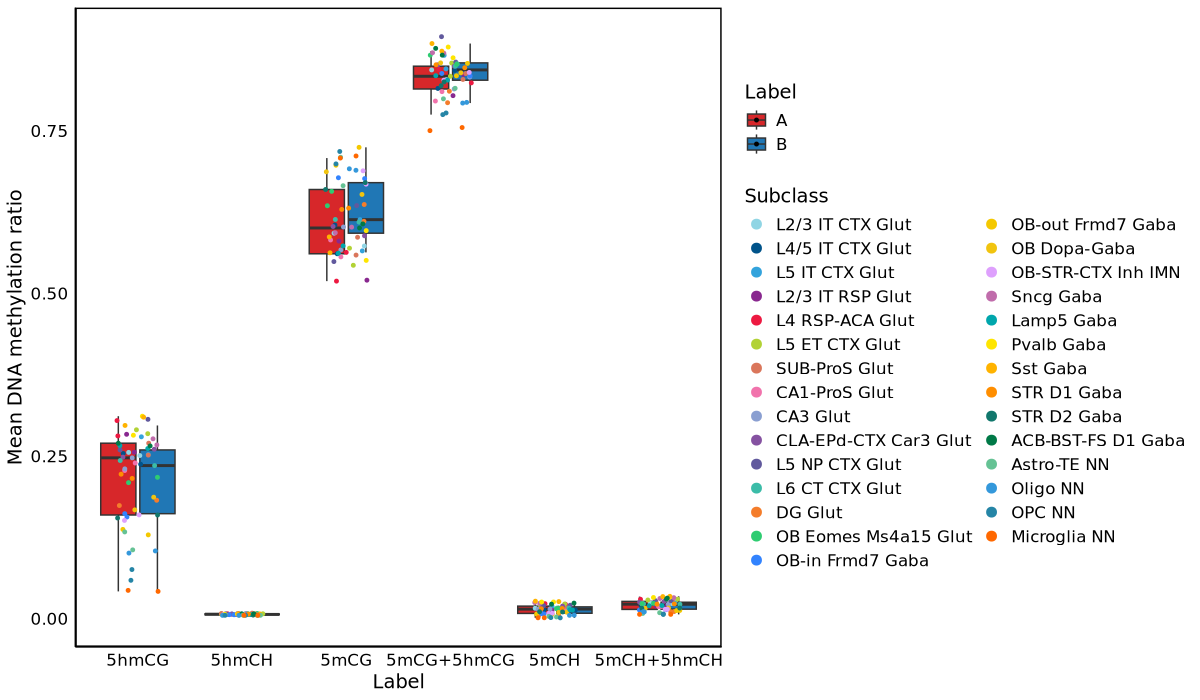

In [137]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)
ggplot(all_mean_long_final, aes(x = group, y = Mean, fill = Label)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(aes(color = Subclass), size = 1, width = 0.2) + 
  scale_fill_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  scale_color_manual(values = subclass_label.col) +
  labs(x = "Label", y = "Mean DNA methylation ratio") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black")
  ) +
  guides(color = guide_legend(override.aes = list(size = 3)))

In [19]:
p1 <- ggplot(mean_long, aes(x = Subclass, y = Mean, color = Label, group = Subclass)) +
  geom_point(size = 3) +
  geom_line(aes(group = Subclass), color = "grey") +
  scale_color_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
  labs(x = "Subclass", y = "Mean 5hmCG ratio", color = "Compartment") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black")
  )

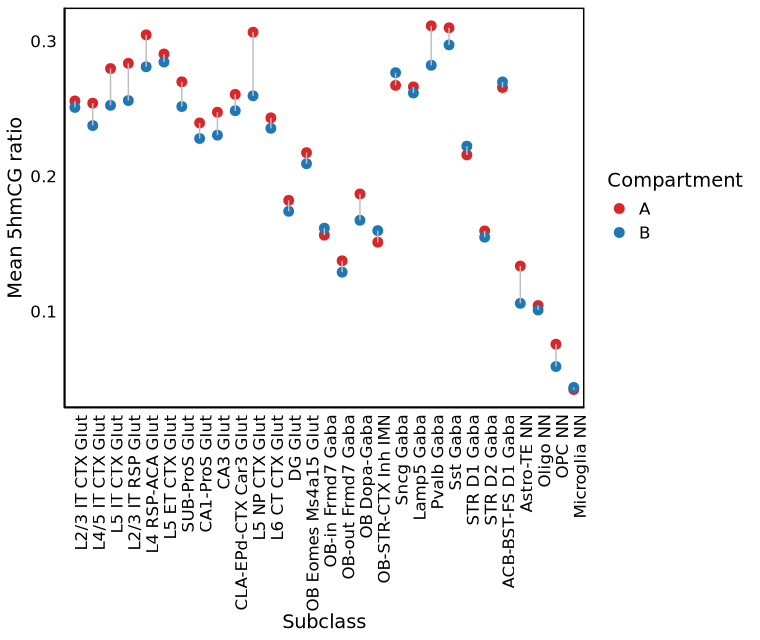

In [20]:
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
p1

In [ ]:
process_subclass_mean <- function(group,label) { # "5hmC_CG","5hmCG"

  data <- read.csv(sprintf("%s/03-%s_chrom100k_subclass_mean_dat_final_with_compartment.csv",indir,group), stringsAsFactors = FALSE, check.names = FALSE)
  
  label_columns <- grep("_compartment$", names(data), value = TRUE)

  mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

  for (label_col in label_columns) {

    main_col <- sub("_compartment$", "", label_col)
    
    if (main_col %in% names(data)) {

      mean_values <- data %>%
        filter(!is.na(.data[[label_col]])) %>%
        group_by(.data[[label_col]]) %>%
        summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
        pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

      A_mean <- mean_values[[paste0(main_col, "_A")]]
      B_mean <- mean_values[[paste0(main_col, "_B")]]

      subclass_results <- data.frame(
        Subclass = main_col,
        A_mean = A_mean,
        B_mean = B_mean,
        stringsAsFactors = FALSE
      )

      mean_results <- rbind(mean_results, subclass_results)
      
    } else {
      warning(paste("Main column not found for label column:", label_col))
    }
  }

  mean_long <- mean_results %>%
    pivot_longer(cols = c(A_mean, B_mean), names_to = "Label", values_to = "Mean") %>%
    mutate(Label = ifelse(Label == "A_mean", "A", "B"),
           Subclass = factor(Subclass, levels = subclass_order))

  p1 <- ggplot(mean_long, aes(x = Subclass, y = Mean, color = Label, group = Subclass)) +
    geom_point(size = 3) +
    geom_line(aes(group = Subclass), color = "grey") +
    scale_color_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
    labs(x = "Subclass", y = sprintf("Mean %s ratio",label), color = "Compartment") +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, color = "black", size = 12),
      axis.text.y = element_text(color = "black", size = 12),
      axis.title = element_text(size = 14),
      legend.text = element_text(size = 12),
      legend.title = element_text(size = 14),
      panel.grid = element_blank(),
      panel.border = element_rect(color = "black", fill = NA, size = 1),
      axis.line = element_line(color = "black")
    )
    
  return(p1)
}

In [22]:
P_hmCG <- process_subclass_mean("5hmC_CG","5hmCG")

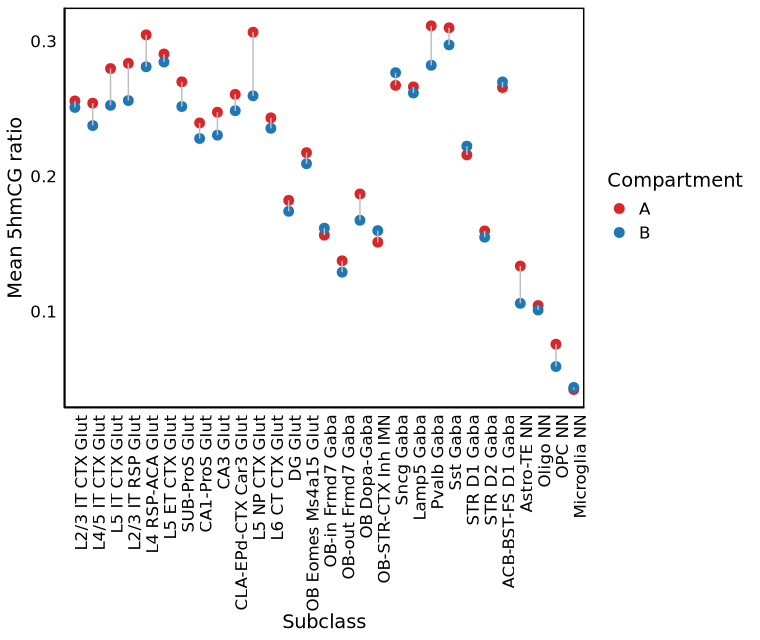

In [23]:
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_hmCG

In [24]:
P_hmCH <- process_subclass_mean("5hmC_CH","5hmCH")

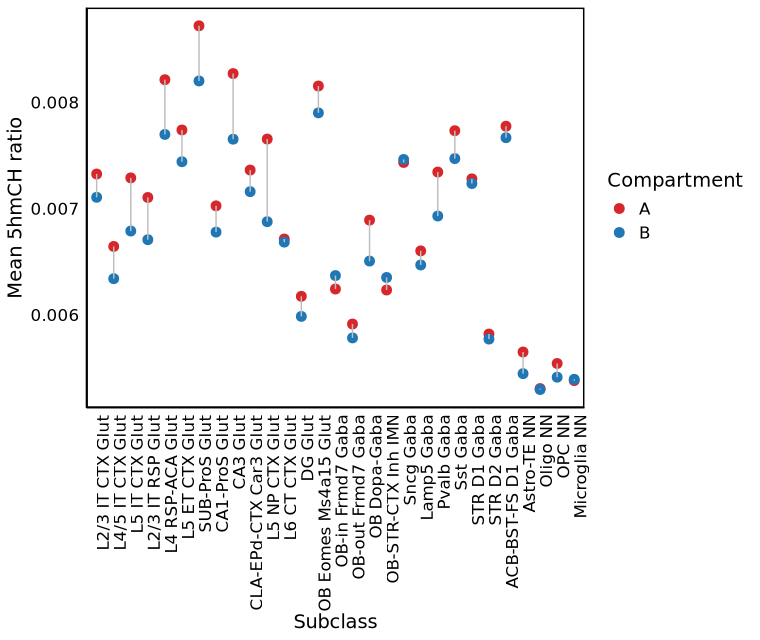

In [25]:
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_hmCH

In [26]:
P_mCG <- process_subclass_mean("5mC_CG","5mCG+5hmCG")

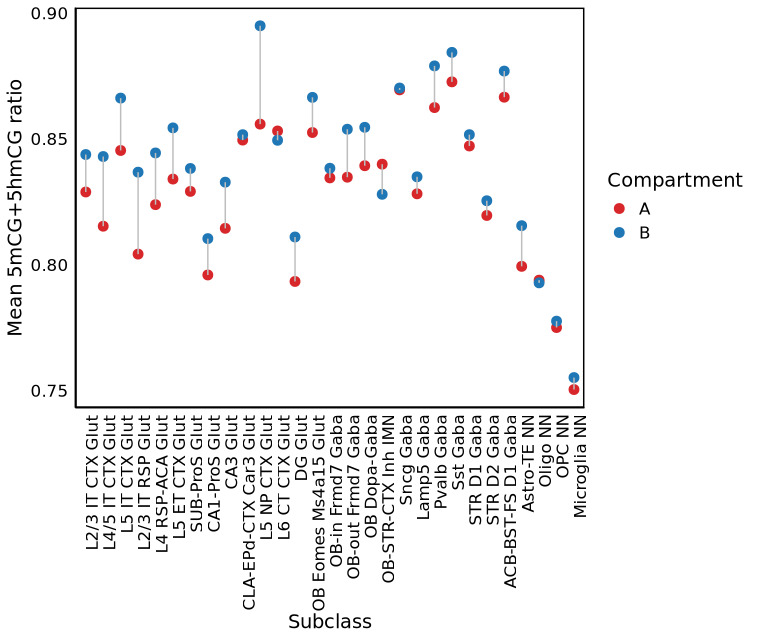

In [27]:
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_mCG

In [28]:
P_mCH <- process_subclass_mean("5mC_CH","5mCH+5hmCH")

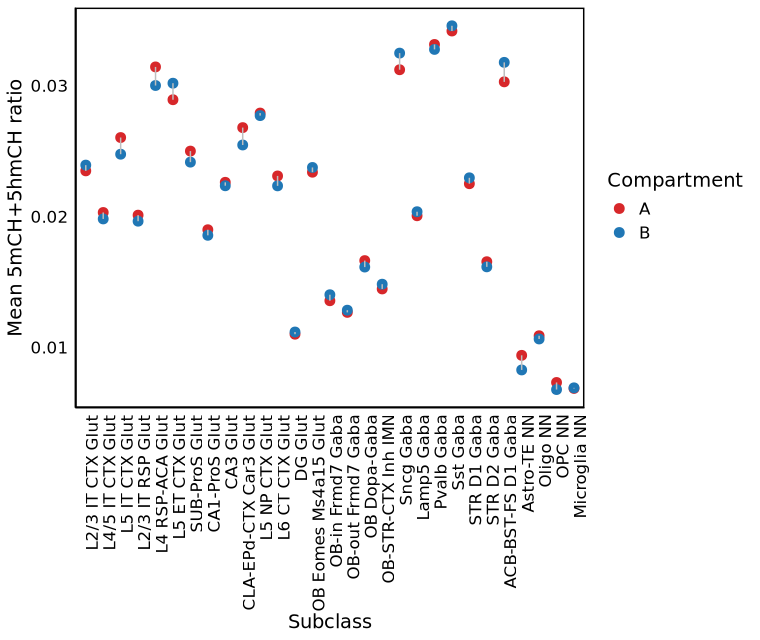

In [29]:
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_mCH

In [ ]:
process_subclass_mean1 <- function(group,label) { # "5hmC_CG","5hmCG"

  data <- read.csv(sprintf("%s/03-%s_chrom100k_subclass_mean_dat_final_with_compartment.csv",indir,group), stringsAsFactors = FALSE, check.names = FALSE)
  
  check_and_fix_first_column_name <- function(data) {
      if (is.na(names(data)[1]) || names(data)[1] == "") {
          names(data)[1] <- "chrom100k"
          print("第一列的列名为空，已更改为 'chrom100k'")
      } else {
          print("第一列的列名为: ", names(data)[1])
      }
      return(data)
  }
  
  data <- check_and_fix_first_column_name(data)
  
  label_columns <- grep("_compartment$", names(data), value = TRUE)

  mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

  for (label_col in label_columns) {

    main_col <- sub("_compartment$", "", label_col)
    
    if (main_col %in% names(data)) {

      mean_values <- data %>%
        filter(!is.na(.data[[label_col]])) %>%
        group_by(.data[[label_col]]) %>%
        summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
        pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

      A_mean <- mean_values[[paste0(main_col, "_A")]]
      B_mean <- mean_values[[paste0(main_col, "_B")]]

      subclass_results <- data.frame(
        Subclass = main_col,
        A_mean = A_mean,
        B_mean = B_mean,
        stringsAsFactors = FALSE
      )

      mean_results <- rbind(mean_results, subclass_results)
      
    } else {
      warning(paste("Main column not found for label column:", label_col))
    }
  }

  mean_long <- mean_results %>%
    pivot_longer(cols = c(A_mean, B_mean), names_to = "Label", values_to = "Mean") %>%
    mutate(Label = ifelse(Label == "A_mean", "A", "B"),
           Subclass = factor(Subclass, levels = subclass_order))

  p1 <- ggplot(mean_long, aes(x = Subclass, y = Mean, color = Label, group = Subclass)) +
    geom_point(size = 3) +
    geom_line(aes(group = Subclass), color = "grey") +
    scale_color_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
    labs(x = "Subclass", y = sprintf("Mean %s ratio",label), color = "Compartment") +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, color = "black", size = 12),
      axis.text.y = element_text(color = "black", size = 12),
      axis.title = element_text(size = 14),
      legend.text = element_text(size = 12),
      legend.title = element_text(size = 14),
      panel.grid = element_blank(),
      panel.border = element_rect(color = "black", fill = NA, size = 1),
      axis.line = element_line(color = "black")
    )
    
  return(p1)
}

[1] "第一列的列名为空，已更改为 'chrom100k'"


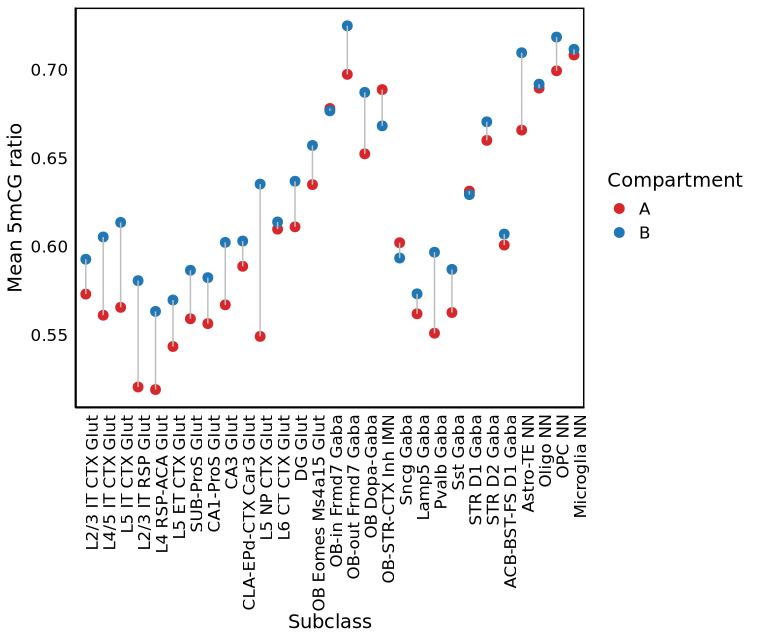

In [31]:
process_subclass_mean1("true5mC_CG","5mCG")

In [32]:
P_true5mC_CG <- process_subclass_mean1("true5mC_CG","5mCG")

[1] "第一列的列名为空，已更改为 'chrom100k'"


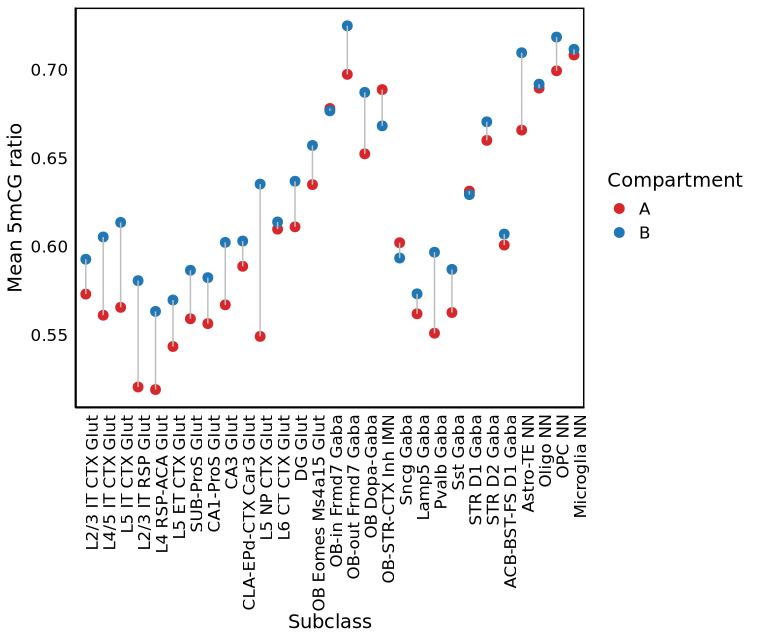

In [33]:
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_true5mC_CG

In [34]:
P_true5mC_CH <- process_subclass_mean1("true5mC_CH","5mCH")

[1] "第一列的列名为空，已更改为 'chrom100k'"


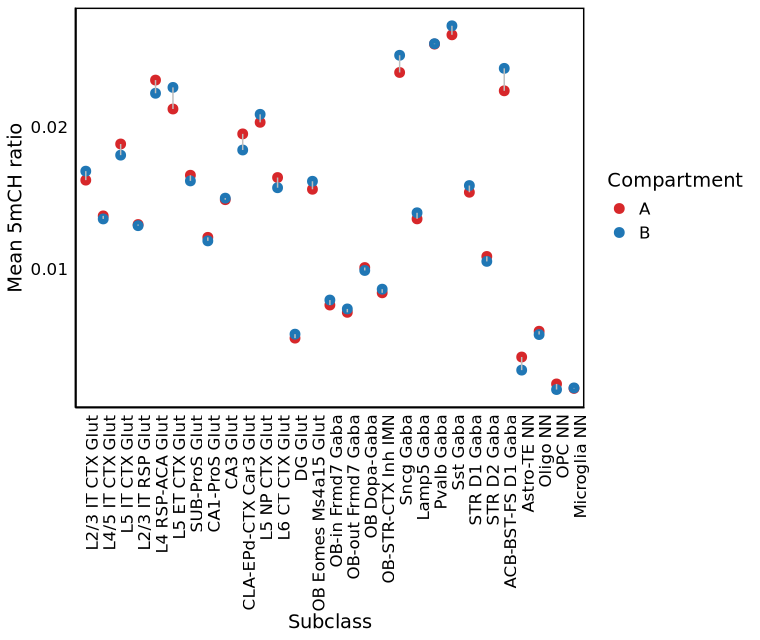

In [35]:
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_true5mC_CH

In [36]:
library(gridExtra)
library(ggplot2)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [37]:
g1 <- arrangeGrob(P_hmCG, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))
g2 <- arrangeGrob(P_true5mC_CG, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))
g3 <- arrangeGrob(P_mCG, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))
g4 <- arrangeGrob(P_hmCH, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))
g5 <- arrangeGrob(P_true5mC_CH, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))
g6 <- arrangeGrob(P_mCH, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))

In [38]:
combined_plot <- arrangeGrob(g1, g2, g3, g4, g5, g6, ncol = 3, nrow = 2)

In [ ]:
ggsave("../../../output/01-youth/05-AB_compartment/04-Subclass_AB_compartment_DNA_methyl_20240923.pdf", combined_plot, width = 23, height = 13)

In [ ]:
process_subclass_mean3 <- function(group,label) { # "5hmC_CG","5hmCG"

  data <- read.csv(sprintf("%s/03-%s_chrom100k_subclass_mean_dat_final_with_compartment.csv",indir,group), stringsAsFactors = FALSE, check.names = FALSE)
  
  label_columns <- grep("_compartment$", names(data), value = TRUE)

  mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

  for (label_col in label_columns) {

    main_col <- sub("_compartment$", "", label_col)
    
    if (main_col %in% names(data)) {

      mean_values <- data %>%
        filter(!is.na(.data[[label_col]])) %>%
        group_by(.data[[label_col]]) %>%
        summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
        pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

      A_mean <- mean_values[[paste0(main_col, "_A")]]
      B_mean <- mean_values[[paste0(main_col, "_B")]]

      subclass_results <- data.frame(
        Subclass = main_col,
        A_mean = A_mean,
        B_mean = B_mean,
        stringsAsFactors = FALSE
      )

      mean_results <- rbind(mean_results, subclass_results)
      
    } else {
      warning(paste("Main column not found for label column:", label_col))
    }
  }

  mean_long <- mean_results %>%
    pivot_longer(cols = c(A_mean, B_mean), names_to = "Label", values_to = "Mean") %>%
    mutate(Label = ifelse(Label == "A_mean", "A", "B"),
           Subclass = factor(Subclass, levels = subclass_order))

  p1 <- ggplot(mean_long, aes(x = Subclass, y = Mean, color = Label)) +
    geom_point(size = 3) +
    geom_line(aes(group = Label), color = "grey") +
    scale_color_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
    labs(x = "Subclass", y = sprintf("Mean %s ratio",label), color = "Compartment") +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, color = "black", size = 12),
      axis.text.y = element_text(color = "black", size = 12),
      axis.title = element_text(size = 14),
      legend.text = element_text(size = 12),
      legend.title = element_text(size = 14),
      panel.grid = element_blank(),
      panel.border = element_rect(color = "black", fill = NA, size = 1),
      axis.line = element_line(color = "black")
    )
  
  return(p1)
}

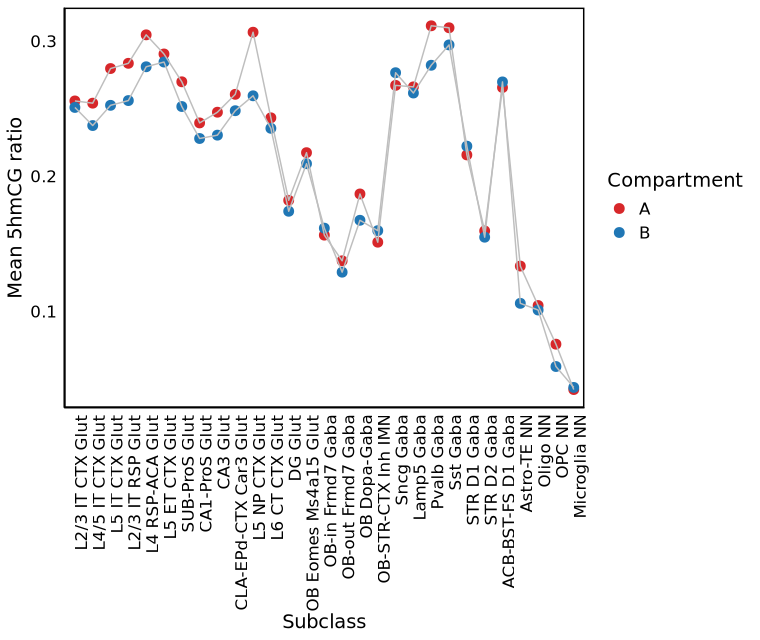

In [45]:
P_hmCG1 <- process_subclass_mean3("5hmC_CG","5hmCG")
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_hmCG1

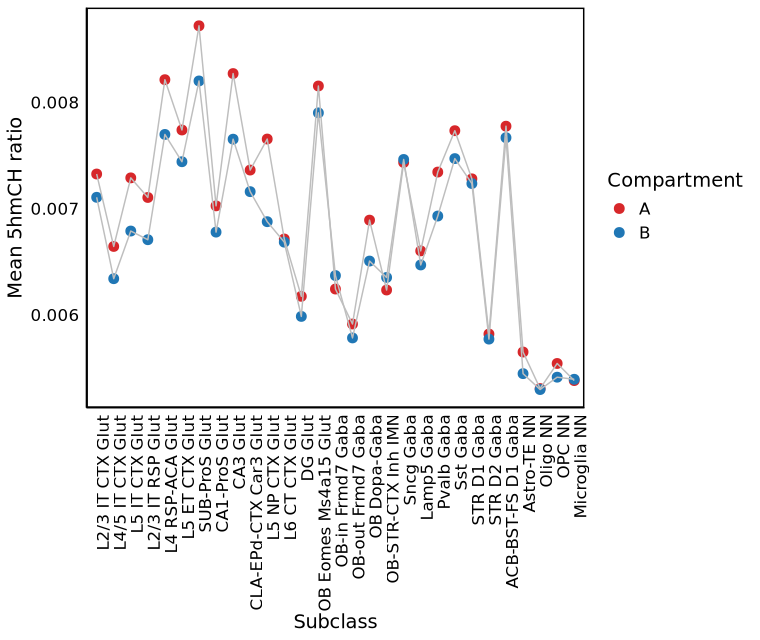

In [47]:
P_hmCH1 <- process_subclass_mean3("5hmC_CH","5hmCH")
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_hmCH1

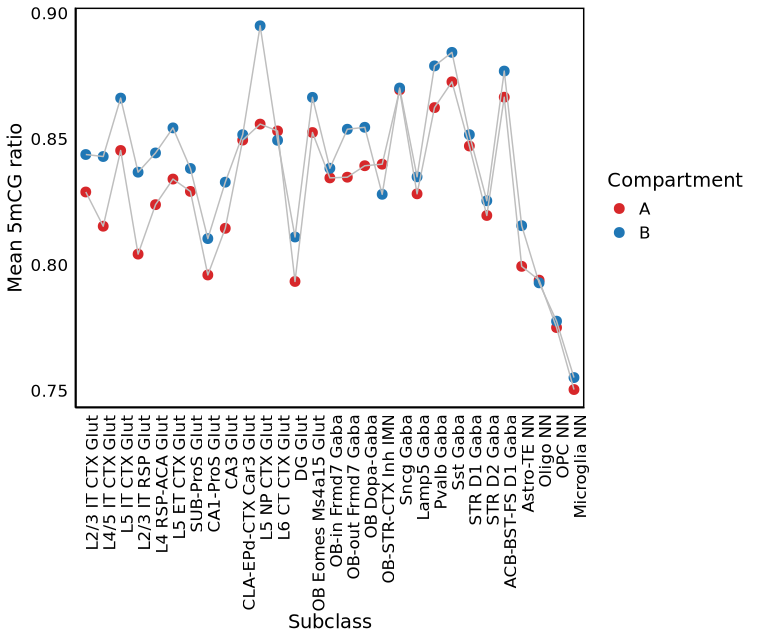

In [48]:
P_mCG1 <- process_subclass_mean3("5mC_CG","5mCG")
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_mCG1

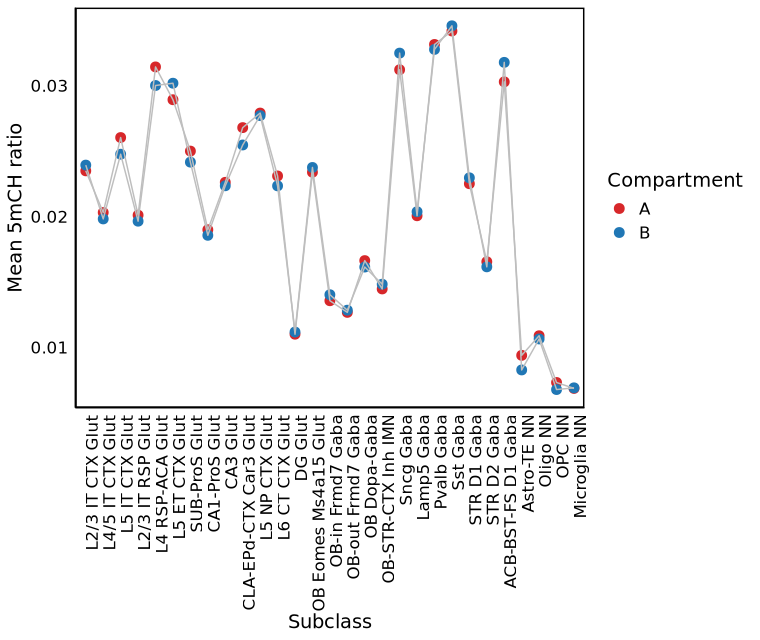

In [49]:
P_mCH1 <- process_subclass_mean3("5mC_CH","5mCH")
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_mCH1

In [ ]:
process_subclass_mean4 <- function(group,label) { # "5hmC_CG","5hmCG"

  data <- read.csv(sprintf("%s/03-%s_chrom100k_subclass_mean_dat_final_with_compartment.csv",indir,group), stringsAsFactors = FALSE, check.names = FALSE)
  
  check_and_fix_first_column_name <- function(data) {
      if (is.na(names(data)[1]) || names(data)[1] == "") {
          names(data)[1] <- "chrom100k"
          print("第一列的列名为空，已更改为 'chrom100k'")
      } else {
          print("第一列的列名为: ", names(data)[1])
      }
      return(data)
  }
  
  data <- check_and_fix_first_column_name(data)
  
  label_columns <- grep("_compartment$", names(data), value = TRUE)

  mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

  for (label_col in label_columns) {

    main_col <- sub("_compartment$", "", label_col)
    
    if (main_col %in% names(data)) {

      mean_values <- data %>%
        filter(!is.na(.data[[label_col]])) %>%
        group_by(.data[[label_col]]) %>%
        summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
        pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

      A_mean <- mean_values[[paste0(main_col, "_A")]]
      B_mean <- mean_values[[paste0(main_col, "_B")]]

      subclass_results <- data.frame(
        Subclass = main_col,
        A_mean = A_mean,
        B_mean = B_mean,
        stringsAsFactors = FALSE
      )

      mean_results <- rbind(mean_results, subclass_results)
      
    } else {
      warning(paste("Main column not found for label column:", label_col))
    }
  }

  mean_long <- mean_results %>%
    pivot_longer(cols = c(A_mean, B_mean), names_to = "Label", values_to = "Mean") %>%
    mutate(Label = ifelse(Label == "A_mean", "A", "B"),
           Subclass = factor(Subclass, levels = subclass_order))

  p1 <- ggplot(mean_long, aes(x = Subclass, y = Mean, color = Label)) +
    geom_point(size = 3) +
    geom_line(aes(group = Label), color = "grey") +
    scale_color_manual(values = c("A" = "#D7272A", "B" = "#2077B5")) +
    labs(x = "Subclass", y = sprintf("Mean %s ratio",label), color = "Compartment") +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, color = "black", size = 12),
      axis.text.y = element_text(color = "black", size = 12),
      axis.title = element_text(size = 14),
      legend.text = element_text(size = 12),
      legend.title = element_text(size = 14),
      panel.grid = element_blank(),
      panel.border = element_rect(color = "black", fill = NA, size = 1),
      axis.line = element_line(color = "black")
    )
    
  return(p1)
}

[1] "第一列的列名为空，已更改为 'chrom100k'"


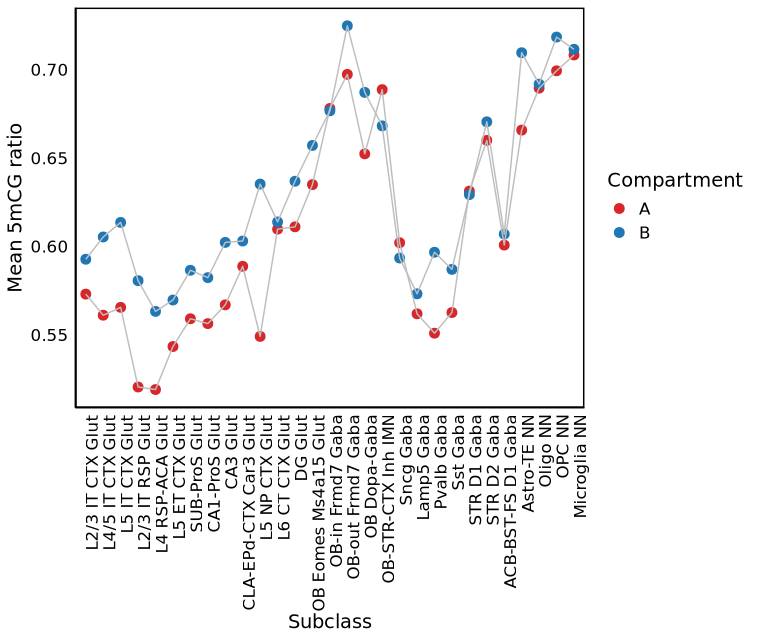

In [51]:
P_true5mC_CG1 <- process_subclass_mean4("true5mC_CG","5mCG")
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_true5mC_CG1

[1] "第一列的列名为空，已更改为 'chrom100k'"


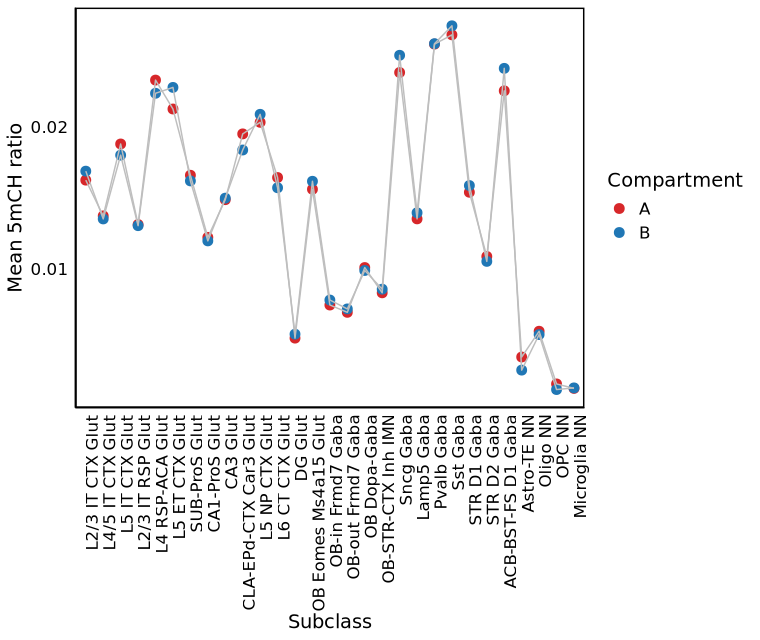

In [52]:
P_true5mC_CH1 <- process_subclass_mean4("true5mC_CH","5mCH")
options(repr.plot.width = 7.6, repr.plot.height = 6.4, repr.plot.res = 100)
P_true5mC_CH1

In [53]:
gg1 <- arrangeGrob(P_hmCG1, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))
gg2 <- arrangeGrob(P_true5mC_CG1, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))
gg3 <- arrangeGrob(P_mCG1, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))
gg4 <- arrangeGrob(P_hmCH1, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))
gg5 <- arrangeGrob(P_true5mC_CH1, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))
gg6 <- arrangeGrob(P_mCH1, heights = unit(6.4, "inches"), widths = unit(7.6, "inches"))

In [54]:
combined_plot1 <- arrangeGrob(gg1, gg2, gg3, gg4, gg5, gg6, ncol = 3, nrow = 2)

In [ ]:
ggsave("../../../output/01-youth/05-AB_compartment/04-Subclass_AB_compartment_DNA_methyl_20240923_line_chart.pdf", combined_plot1, width = 23, height = 13)